In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("customer_churn_dataset-training-master.csv")

df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [4]:
df = df.drop(columns = 'CustomerID')

In [5]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df['Churn'].value_counts(normalize = True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

### Sem problemas de desbalanceamento

In [6]:
df.isna().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [7]:
df.dropna()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [8]:
for column in df.columns:
    print(f'O tipo da coluna {column} é {df[column].dtype}')

O tipo da coluna Age é float64
O tipo da coluna Gender é object
O tipo da coluna Tenure é float64
O tipo da coluna Usage Frequency é float64
O tipo da coluna Support Calls é float64
O tipo da coluna Payment Delay é float64
O tipo da coluna Subscription Type é object
O tipo da coluna Contract Length é object
O tipo da coluna Total Spend é float64
O tipo da coluna Last Interaction é float64
O tipo da coluna Churn é float64


In [9]:
print(df[['Gender', 'Churn']].groupby('Gender').count()/len(df))
print(100 * '-')
print(df[['Subscription Type', 'Churn']].groupby('Subscription Type').count()/len(df))
print(100 * '-')
print(df[['Contract Length', 'Churn']].groupby('Contract Length').count()/len(df))

           Churn
Gender          
Female  0.432318
Male    0.567680
----------------------------------------------------------------------------------------------------
                      Churn
Subscription Type          
Basic              0.324445
Premium            0.337266
Standard           0.338287
----------------------------------------------------------------------------------------------------
                    Churn
Contract Length          
Annual           0.401962
Monthly          0.197590
Quarterly        0.400446


#### Temos variáveis qualitativas do tipo string que podem ser cruciais para a informação do modelo, e para utilizá-las, transformarei em dummies, ao mesmo tempo que inutilizo as features originais

In [10]:
Gender_dummie = pd.get_dummies(df['Gender'], dtype = int)
Subscription_dummie = pd.get_dummies(df['Subscription Type'], dtype = int)
Contract_Length_dummie = pd.get_dummies(df['Contract Length'], dtype = int)

df = pd.concat([df.drop(columns = ['Gender', 'Subscription Type', 'Contract Length']), Gender_dummie, Subscription_dummie, Contract_Length_dummie], axis = 1)
df

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Basic,Premium,Standard,Annual,Monthly,Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,1,0,0,0,1,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,1,0,1,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,1,0,1,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,0,1,0,0,1,0,1,0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,0,1,0,1,0,1,0,0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,1,0,0,1,0,1,0,0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,0,1,0,0,1,0,0,1
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,0,1,0,0,1,0,0,1


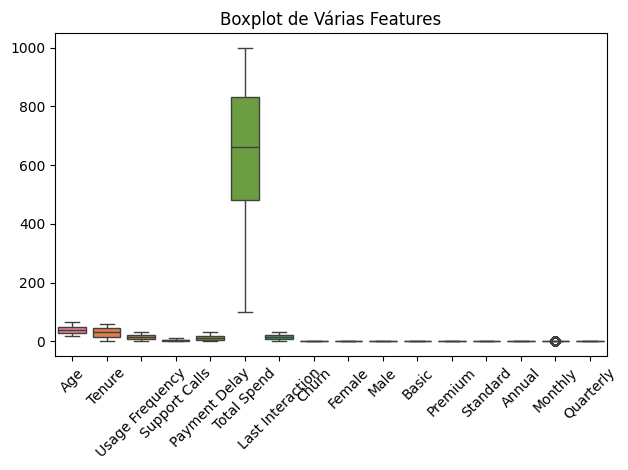

In [11]:
sns.boxplot(data=df)

plt.title("Boxplot de Várias Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Monthly apresenta outlier, mas é uma variável dummie, sendo assim é impossível ter outliers, o que acontece é que a proporção de 0 e 1 está desbalanceada

In [12]:
df[['Monthly', 'Churn']].groupby('Monthly').count()/len(df)

,Churn
Monthly,
0,0.802408
1,0.197590


#### Pelo fato do tipo de modelo necessitar ser classificação, vou primeiro testar modelos baseados em árvore, assim não preciso fazer normalização dos dados por agora

In [32]:
corr = df.corr()

corr

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Basic,Premium,Standard,Annual,Monthly,Quarterly
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394,0.031419,-0.031419,0.004768,-0.002873,-0.001847,-0.034986,0.086909,-0.035617
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919,-0.007978,0.007978,0.027270,-0.015415,-0.011580,0.009021,-0.020637,0.007744
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101,-0.007978,0.007978,0.000096,0.000149,-0.000244,0.006943,-0.017820,0.007534
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267,0.091212,-0.091212,0.010780,-0.006219,-0.004453,-0.091068,0.223242,-0.090289
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129,0.048449,-0.048449,0.005085,-0.004229,-0.000805,-0.049697,0.122674,-0.049961
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355,-0.066138,0.066138,-0.008469,0.003882,0.004501,0.068365,-0.166916,0.067234
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616,-0.134786,0.134786,0.000615,-0.000438,-0.000171,-0.023342,0.057563,-0.023421
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000,0.175395,-0.175395,0.020526,-0.011072,-0.009247,-0.175965,0.433553,-0.176244
Female,0.031419,-0.007978,-0.007978,0.091212,0.048449,-0.066138,-0.134786,0.175395,1.000000,-0.999995,0.000727,-0.003188,0.002471,-0.029390,0.067612,-0.025532
Male,-0.031419,0.007978,0.007978,-0.091212,-0.048449,0.066138,0.134786,-0.175395,-0.999995,1.000000,-0.000724,0.003191,-0.002468,0.029393,-0.067610,0.025535


In [19]:
from sklearn.ensemble import RandomForestClassifier as rf
from xgboost import XGBClassifier as xgb
from lightgbm import LGBMClassifier as lgbm
from sklearn.linear_model import LogisticRegression as lr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, accuracy_score, confusion_matrix

In [20]:
x = df.drop(columns = 'Churn')
y = df['Churn']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### Definindo melhores parâmetros com Optuna, que automatiza a escolha do melhor modelo e seus hiperparâmetros através de uma otimização bayesiana

In [22]:
import optuna

In [ ]:
# Criar a função para optuna iniciar a otimização bayesiana

def objective(trial):
    # Escolher o modelo
    model_name = trial.suggest_categorical("model", ["rf", "xgb", "lgbm", "lr"])

    if model_name == "rf":
        n_estimators = trial.suggest_int("rf_n_estimators", 100, 500)
        max_depth = trial.suggest_int("rf_max_depth", 2, 15)
        clf = rf(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

    elif model_name == "xgb":
        n_estimators = trial.suggest_int("xgb_n_estimators", 100, 500)
        max_depth = trial.suggest_int("xgb_max_depth", 2, 15)
        eta = trial.suggest_float("xgb_eta", 0.01, 0.1, log=True)
        clf = xgb(n_estimators=n_estimators, max_depth=max_depth, eta=eta, eval_metric = 'auc', random_state=42)

    elif model_name == "lgbm":
        n_estimators = trial.suggest_int("lgbm_n_estimators", 100, 500)
        num_leaves = trial.suggest_int("lgbm_num_leaves", 20, 100)
        learning_rate = trial.suggest_float("lgbm_lr", 0.01, 0.1, log=True)
        clf = lgbm(n_estimators=n_estimators, num_leaves=num_leaves, learning_rate=learning_rate, random_state=42)

    elif model_name == "lr":
        c = trial.suggest_float("lr_C", 1e-4, 10.0, log=True)
        clf = lr(C=c, solver="liblinear", random_state=42)

    mask = y_train.notna()

    # Avaliar com validação cruzada
    scores = cross_val_score(clf, x_train[mask], y_train[mask].astype(int), cv = 5, scoring = 'roc_auc')

    return scores.mean()

# Criar estudo e otimizar, maximizando o score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

# Mostrar o melhor resultado
print("Melhor modelo e hiperparâmetros:", study.best_params)
print("Melhor score:", study.best_value)

### Apesar de demorado, o Optuna usa o método de otimização bayesiana, que é mais inteligente do que métodos simples como GridSearch ou RandomSearch. Testando alguns modelos diferentes, o **XGBoost** apresentou uma melhor pontuação utilizando AUC, chegando a quase 1 no treino, ou seja, ordena bem independente dos limiares de decisão, o que é muito importante em churn.

In [45]:
from xgboost import XGBClassifier as xgb

xgb = xgb(
    n_estimators=459,
    max_depth=7,
    learning_rate=0.03468575651290695,
    eval_metric='auc',
    random_state=42
)

mask = y_train.notna()
xgb.fit(x_train[mask], y_train[mask].astype(int))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03468575651290695, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=459, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
importance = xgb.feature_importances_

# Emparelhar colunas com importância
feature_importance = list(zip(x_train.columns, importance))

# Ordenar pelo valor da importância, do maior para o menor
feature_importance.sort(key=lambda x: x[1], reverse=True)

# Imprimir
for feature, imp in feature_importance:
    print(f'{feature}: {imp}')


Monthly: 0.2569064199924469
Total Spend: 0.24196527898311615
Support Calls: 0.20031137764453888
Payment Delay: 0.1501583307981491
Female: 0.07019603252410889
Age: 0.04854583740234375
Basic: 0.009614174254238605
Last Interaction: 0.009136869572103024
Tenure: 0.008122644387185574
Usage Frequency: 0.004480792675167322
Premium: 0.00017233763355761766
Quarterly: 0.00016710882482584566
Annual: 0.0001418444444425404
Standard: 8.099220576696098e-05
Male: 0.0


In [ ]:
# Quero usar a curva ROC AUC para avaliar a capacidade do meu modelo de distinguir as classes
y_test = y_test.to_numpy()

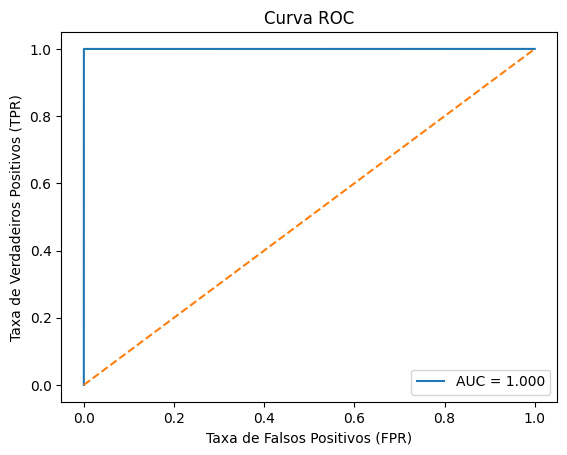

In [ ]:
y_pred_prob = xgb.predict_proba(x_test)[:, 1]  # probabilidade da classe positiva
auc_roc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, label = f"AUC = {auc_roc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--") 
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()


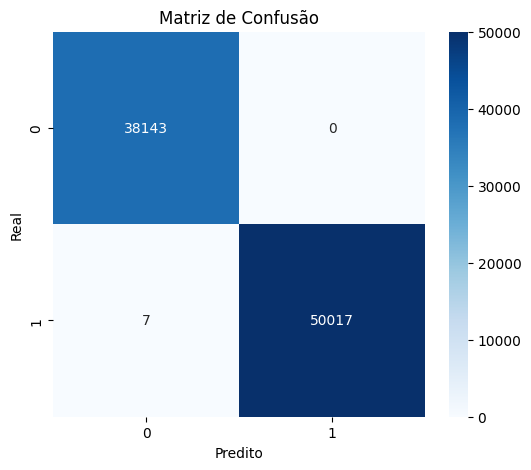

In [ ]:
matrix = confusion_matrix(y_pred = y_pred, y_true = y_test)

plt.figure(figsize=(6,5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='')

plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()